# Importing Required Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

# Loading the Dataset

In [2]:
df = pd.read_csv('iris.csv')
print(f"Dataset loaded into dataframe df, having shape : {df.shape}")

Dataset loaded into dataframe df, having shape : (150, 6)


# Exploring the Dataset

## Dimension and Size

In [3]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}\nTotal No. of Cells : {df.size}")

No. of Rows : 150
No. of Columns : 6
Total No. of Cells : 900


## Displaying Sample Rows

In [4]:
print("Top 5 rows")
display(df.head())

Top 5 rows


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print("Last 5 rows")
display(df.tail())

Last 5 rows


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
print("Randomly selected 5 rows")
display(df.sample(5))

Randomly selected 5 rows


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
27,28,5.2,3.5,1.5,0.2,Iris-setosa
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor
115,116,6.4,3.2,5.3,2.3,Iris-virginica
64,65,5.6,2.9,3.6,1.3,Iris-versicolor


## Metadata

In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

## Statistical Summary

In [8]:
display(df.describe())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Data Preprocessing

## Dropping Irrelevant Column

In [9]:
df.drop('Id',axis=1,inplace=True)

## Converting to Suitable DataTypes

In [10]:
print("Before Type Conversion")
display(df.dtypes)

Before Type Conversion


SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [11]:
print("Memory Usage Before Converting to Category Columns")
df.memory_usage(deep=True).sum()

Memory Usage Before Converting to Category Columns


np.int64(14282)

In [12]:
df['Species'] = df['Species'].astype('category')

In [13]:
print("After Type Conversion")
display(df.dtypes)

After Type Conversion


SepalLengthCm     float64
SepalWidthCm      float64
PetalLengthCm     float64
PetalWidthCm      float64
Species          category
dtype: object

In [14]:
print("Memory Usage After Converting to Category Columns")
df.memory_usage(deep=True).sum()

Memory Usage After Converting to Category Columns


np.int64(5377)

## Identifying NULL Values

In [15]:
df.isnull()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [16]:
print(f"No. of NULL Values per Column\n{df.isnull().sum()}\n-----------------------------------------\nTotal No. of NULL Values : {df.isnull().sum().sum()}")

No. of NULL Values per Column
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
-----------------------------------------
Total No. of NULL Values : 0


## Detecting Outliers

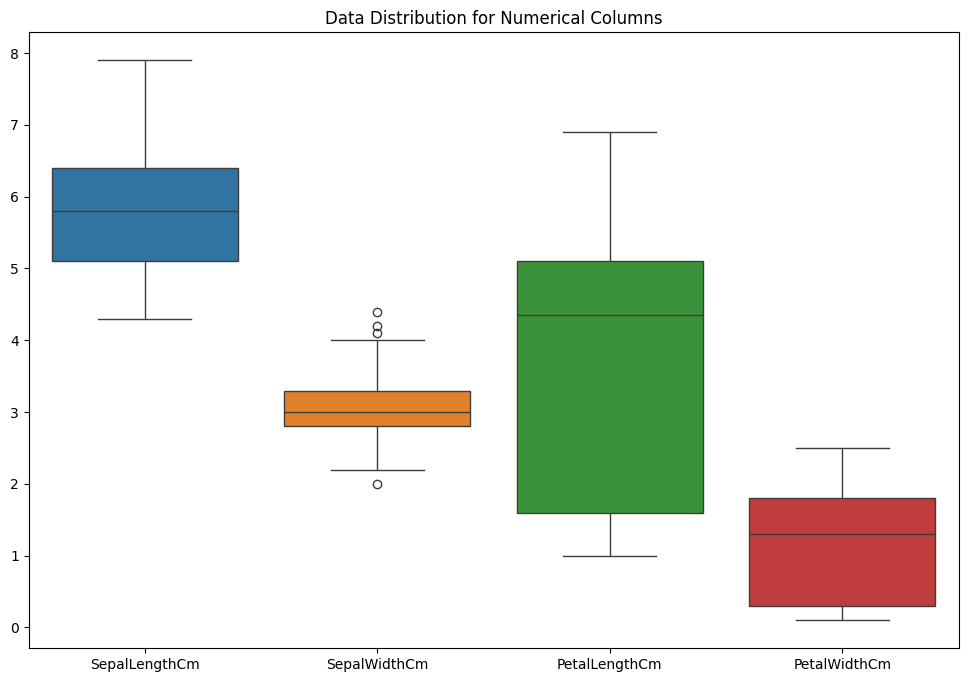

In [17]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop('Species',axis=1))
plt.title("Data Distribution for Numerical Columns")
plt.show()

# Quick EDA

## CountPlot for Species

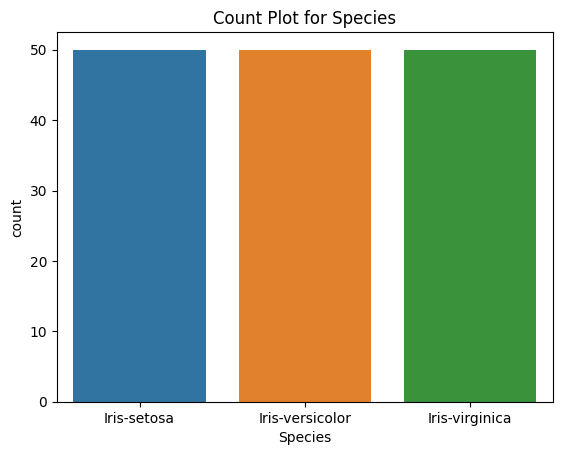

In [21]:
sns.countplot(data=df, x='Species', hue='Species')
plt.title("Count Plot for Species")
plt.show()

In [24]:
print(df.groupby('Species').count())

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa                 50            50             50            50
Iris-versicolor             50            50             50            50
Iris-virginica              50            50             50            50


C:\Users\Karunya\AppData\Local\Temp\ipykernel_5408\266873280.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Species').count())


## ViolinPlot for Species

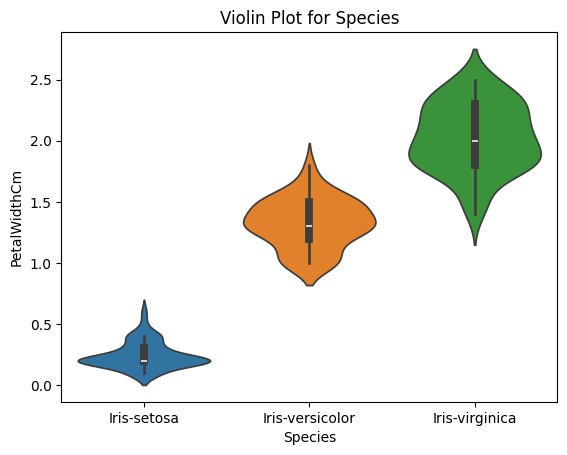

In [26]:
sns.violinplot(data=df,x='Species',y='PetalWidthCm',hue='Species')
plt.title("Violin Plot for Species")
plt.show()

## Correlation Matrix

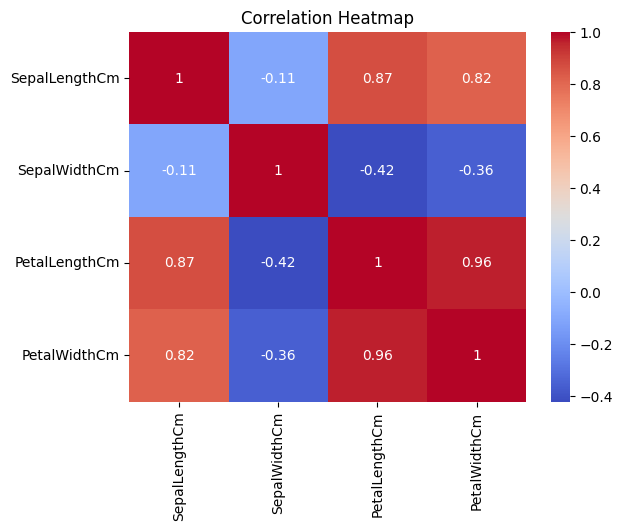

In [28]:
sns.heatmap(data=df.drop('Species',axis=1).corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Model Training

## Assigning Target and Independent Features

In [29]:
x = df.drop('Species',axis=1)
y = df['Species']
print(f"Independent Features : {x.columns}\nDependent Feature : {y.name}")

Independent Features : Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')
Dependent Feature : Species


## Splitting into Training and Testing Dataset

In [30]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

## Training the Naive Bayes Model

In [31]:
model = GaussianNB()

In [32]:
model.fit(X_train, y_train)

GaussianNB()

# Model Evaluation

In [34]:
y_pred = model.predict(X_test)

In [35]:
display(y_pred[:5])

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor'], dtype='<U15')

In [36]:
display(y_test.head())

73     Iris-versicolor
18         Iris-setosa
118     Iris-virginica
78     Iris-versicolor
76     Iris-versicolor
Name: Species, dtype: category
Categories (3, object): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

## Confusion Matrix

In [38]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [43]:
total = np.sum(cm)
for i in range(len(cm)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - TP #sum of column i (predicted as class i) minus TP
    fn = np.sum(cm[i, :]) - TP #sum of row i (actual class i) minus TP
    tn = total - TP - FP - FN
    print(f"Class {i}: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

Class 0: TP=15, FP=3, FN=3, TN=26
Class 1: TP=11, FP=-1, FN=-1, TN=26
Class 2: TP=12, FP=0, FN=0, TN=26


## Deriving Metrics from Confusion Matrix

In [44]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
error_rate = 1 - accuracy
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

In [45]:
print(f"\nAccuracy     : {accuracy:.2f}")
print(f"Error Rate   : {error_rate:.2f}")
print(f"Precision    : {precision:.2f}")
print(f"Recall       : {recall:.2f}")
print(f"F1-Score     : {f1_score:.2f}")


Accuracy     : 1.00
Error Rate   : 0.00
Precision    : 1.00
Recall       : 1.00
F1-Score     : 1.00


## Visualization

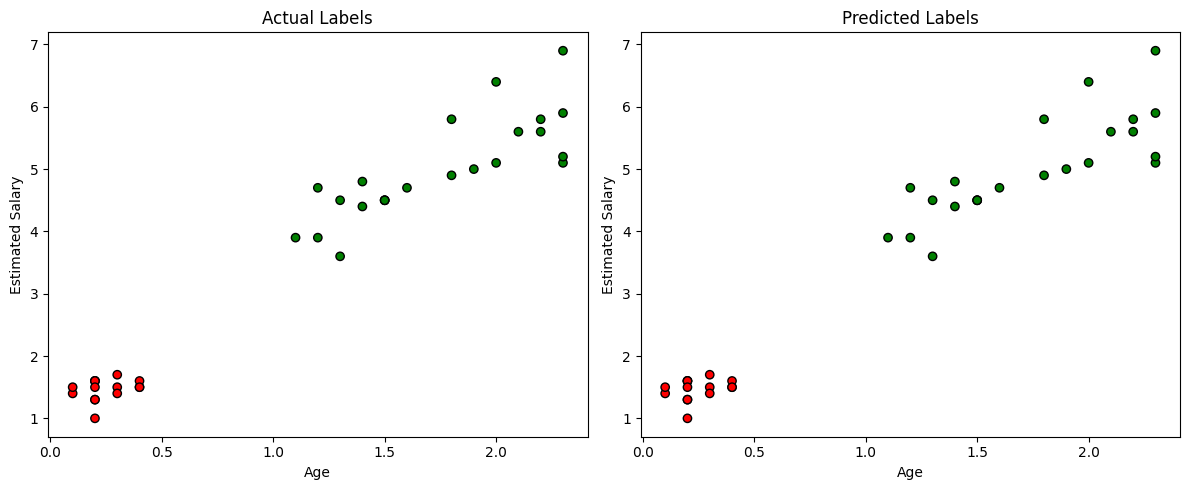

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Actual labels
axs[0].scatter(X_test['PetalWidthCm'], X_test['PetalLengthCm'], c=y_test.cat.codes, cmap=ListedColormap(['red', 'green']), edgecolor='k')
axs[0].set_title('Actual Labels')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Estimated Salary')

# Predicted labels
axs[1].scatter(X_test['PetalWidthCm'], X_test['PetalLengthCm'], c=pd.Series(y_pred).astype('category').cat.codes, cmap=ListedColormap(['red', 'green']), edgecolor='k')
axs[1].set_title('Predicted Labels')
axs[1].set_xlabel('Age')
axs[1].set_ylabel('Estimated Salary')

plt.tight_layout()
plt.show()

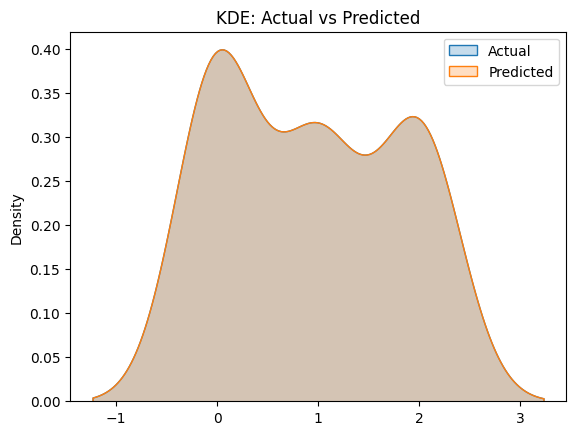

In [50]:
sns.kdeplot(y_test.cat.codes, label='Actual', fill=True)
sns.kdeplot(pd.Series(y_pred).astype('category').cat.codes, label='Predicted', fill=True)
plt.title("KDE: Actual vs Predicted")
plt.legend()
plt.show()